# C1: BiLSTM Single vs. Pileup Classifier

Binary classifier using a bidirectional LSTM to distinguish single-pulse
events from synthetic pileup events. This is the first stage (C1) of the
proposed pipeline.

- **Input**: Euclidean-normalized waveforms (104 timesteps)
- **Output**: 0 = single pulse, 1 = pileup

In [1]:
import numpy as np
import tensorflow as tf
from tensorflow import keras
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

print(f"TensorFlow {tf.__version__}")
print(f"GPUs: {tf.config.list_physical_devices('GPU')}")

I0000 00:00:1774405526.306189   68074 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1774405526.944831   68074 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


TensorFlow 2.22.0-dev0+selfbuilt
GPUs: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


## Load and combine data

Single pulses come from `processed_waveforms.npz`, pileup events from
`pileup_waveforms.npz`. We Euclidean-normalize the pileup waveforms to
match the single-pulse input format.

In [2]:
# --- Load single-pulse data ---
singles = np.load("processed_waveforms.npz")
X_singles = singles["X_voltage"].astype(np.float32)
n_singles = X_singles.shape[0]

# --- Load pileup data ---
pileups = np.load("pileup_waveforms.npz")
X_pileup = pileups["pileup_wf"].astype(np.float32)
n_pileup = X_pileup.shape[0]

print(f"Singles: {n_singles:,}  |  Pileup: {n_pileup:,}")

Singles: 520,010  |  Pileup: 400,000


In [3]:
# Balance classes by subsampling the larger group
rng = np.random.default_rng(42)
n_balanced = min(n_singles, n_pileup)

single_idx = rng.choice(n_singles, size=n_balanced, replace=False)
pileup_idx = rng.choice(n_pileup, size=n_balanced, replace=False)

# Combine
X_all = np.concatenate([X_singles[single_idx], X_pileup[pileup_idx]], axis=0)
y_all = np.concatenate([
    np.zeros(n_balanced, dtype=np.int64),  # 0 = single
    np.ones(n_balanced, dtype=np.int64),   # 1 = pileup
])

# Euclidean-normalize all waveforms
norms = np.linalg.norm(X_all, axis=1, keepdims=True)
norms[norms == 0] = 1.0
X_all = X_all / norms

# Shuffle
shuffle = rng.permutation(len(y_all))
X_all = X_all[shuffle]
y_all = y_all[shuffle]

print(f"Combined: {X_all.shape}")
print(f"Single: {(y_all==0).sum():,}  |  Pileup: {(y_all==1).sum():,}")

Combined: (800000, 104)
Single: 400,000  |  Pileup: 400,000


In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X_all, y_all, test_size=0.2, random_state=42, stratify=y_all
)

# Keras LSTM expects (batch, timesteps, features)
X_train = X_train[..., np.newaxis]  # (N, 104, 1)
X_test  = X_test[..., np.newaxis]

print(f"Train: {X_train.shape}  |  Test: {X_test.shape}")

Train: (640000, 104, 1)  |  Test: (160000, 104, 1)


## Model

In [5]:
model = keras.Sequential([
    keras.layers.Input(shape=(104, 1)),
    keras.layers.Bidirectional(
        keras.layers.LSTM(64, return_sequences=True, dropout=0.3)
    ),
    keras.layers.Bidirectional(
        keras.layers.LSTM(64, dropout=0.3)
    ),
    keras.layers.Dense(32, activation="relu"),
    keras.layers.Dropout(0.3),
    keras.layers.Dense(1, activation="sigmoid"),
])

model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss="binary_crossentropy",
    metrics=["accuracy"],
)

model.summary()

I0000 00:00:1774405529.422840   68074 gpu_device.cc:2043] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 11547 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 5070 Ti, pci bus id: 0000:01:00.0, compute capability: 12.0a


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ bidirectional (Bidirectional)   │ (None, 104, 128)       │        33,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_1 (Bidirectional) │ (None, 128)            │        98,816 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │         4,128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 136,769 (534.25 KB)

 Trainable params: 136,769 (534.25 KB)

 Non-trainable params: 0 (0.00 B)

## Train

In [6]:
callbacks = [
    keras.callbacks.ReduceLROnPlateau(patience=3, factor=0.5, verbose=1),
    keras.callbacks.EarlyStopping(patience=7, restore_best_weights=True, verbose=1),
]

history = model.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    epochs=30,
    batch_size=512,
    callbacks=callbacks,
)

Epoch 1/30


I0000 00:00:1774405531.857568   68236 cuda_dnn.cc:461] Loaded cuDNN version 91900


1250/1250 ━━━━━━━━━━━━━━━━━━━━ 23s 17ms/step - accuracy: 0.8752 - loss: 0.2553 - val_accuracy: 0.9246 - val_loss: 0.1940 - learning_rate: 0.0010
Epoch 2/30
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 21s 17ms/step - accuracy: 0.8958 - loss: 0.2147 - val_accuracy: 0.9248 - val_loss: 0.2116 - learning_rate: 0.0010
Epoch 3/30
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 21s 17ms/step - accuracy: 0.9029 - loss: 0.2019 - val_accuracy: 0.9280 - val_loss: 0.1896 - learning_rate: 0.0010
Epoch 4/30
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 22s 17ms/step - accuracy: 0.9098 - loss: 0.1873 - val_accuracy: 0.9430 - val_loss: 0.1430 - learning_rate: 0.0010
Epoch 5/30
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 22s 18ms/step - accuracy: 0.9154 - loss: 0.1744 - val_accuracy: 0.9427 - val_loss: 0.1601 - learning_rate: 0.0010
Epoch 6/30
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 22s 17ms/step - accuracy: 0.9193 - loss: 0.1652 - val_accuracy: 0.9457 - val_loss: 0.1411 - learning_rate: 0.0010
Epoch 7/30
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 21s 17ms/step - accuracy: 0.9225 

## Results

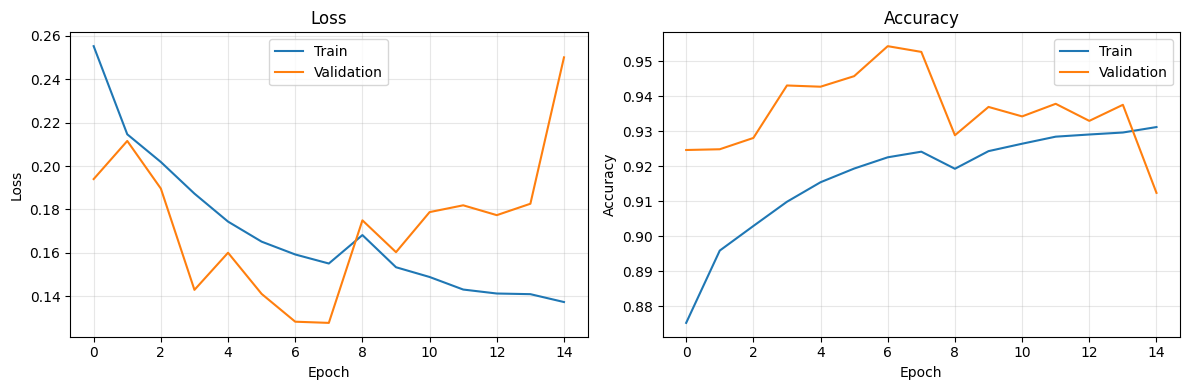

In [7]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(history.history["loss"], label="Train")
ax1.plot(history.history["val_loss"], label="Validation")
ax1.set_xlabel("Epoch")
ax1.set_ylabel("Loss")
ax1.set_title("Loss")
ax1.legend()
ax1.grid(True, alpha=0.3)

ax2.plot(history.history["accuracy"], label="Train")
ax2.plot(history.history["val_accuracy"], label="Validation")
ax2.set_xlabel("Epoch")
ax2.set_ylabel("Accuracy")
ax2.set_title("Accuracy")
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

157/157 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step
              precision    recall  f1-score   support

      Single       0.94      0.97      0.95     80000
      Pileup       0.97      0.94      0.95     80000

    accuracy                           0.95    160000
   macro avg       0.95      0.95      0.95    160000
weighted avg       0.95      0.95      0.95    160000



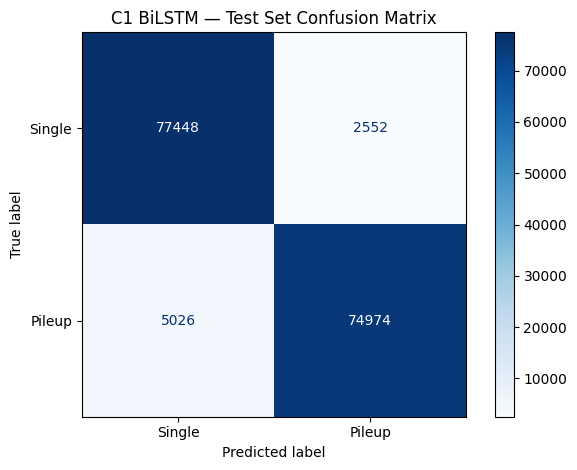

In [8]:
y_prob = model.predict(X_test, batch_size=1024).squeeze()
y_pred = (y_prob > 0.5).astype(int)

print(classification_report(y_test, y_pred, target_names=["Single", "Pileup"]))

cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(cm, display_labels=["Single", "Pileup"])
disp.plot(cmap="Blues")
plt.title("C1 BiLSTM — Test Set Confusion Matrix")
plt.tight_layout()
plt.show()

In [9]:
model.save("c1_bilstm_single_vs_pileup.keras")
print("Model saved to c1_bilstm_single_vs_pileup.keras")

Model saved to c1_bilstm_single_vs_pileup.keras


## Accuracy vs. pileup delay

Evaluate C1 separately for each delay value (in samples) to see how
classification accuracy degrades as pileup pulses get closer together.

391/391 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step


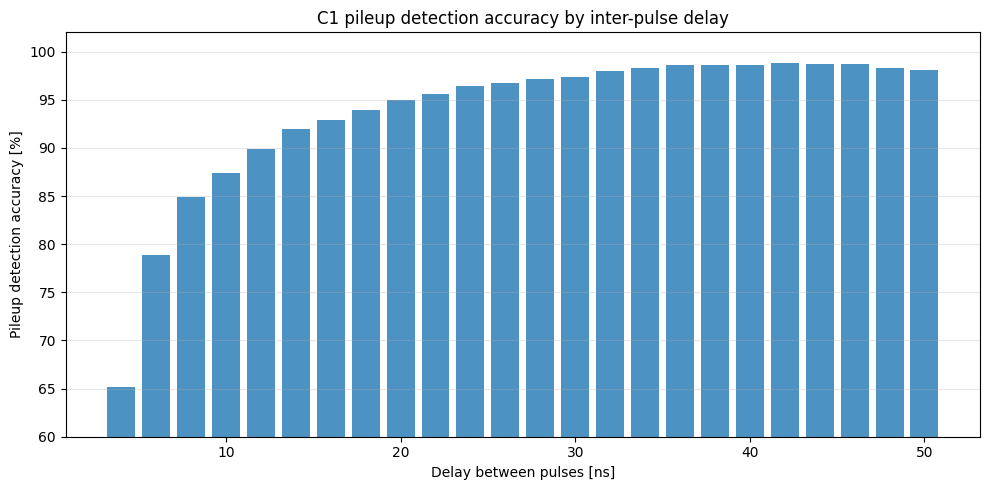

  Delay (ns)   Delay (samples)     Count    Accuracy
----------------------------------------------------
           4                 2    16,736      65.17%
           6                 3    16,841      78.84%
           8                 4    16,640      84.91%
          10                 5    16,674      87.40%
          12                 6    16,680      89.90%
          14                 7    16,683      91.98%
          16                 8    16,761      92.93%
          18                 9    16,506      93.92%
          20                10    16,310      95.02%
          22                11    16,752      95.63%
          24                12    16,786      96.47%
          26                13    16,772      96.79%
          28                14    16,785      97.12%
          30                15    16,809      97.41%
          32                16    16,810      97.99%
          34                17    16,490      98.31%
          36                18    16,429      

In [ ]:
# Build per-delay test sets from the pileup data directly
pileup_delays = pileups["delays_samples"] 

# Euclidean-normalize pileup waveforms the same way as training.
X_pileup_norm = X_pileup.copy()
norms_p = np.linalg.norm(X_pileup_norm, axis=1, keepdims=True)
norms_p[norms_p == 0] = 1.0
X_pileup_norm = X_pileup_norm / norms_p

unique_delays = np.sort(np.unique(pileup_delays))
delay_ns = unique_delays * 2.0  # convert samples to ns

# Predict on all pileup waveforms at once
X_pileup_input = X_pileup_norm[..., np.newaxis]
pileup_probs = model.predict(X_pileup_input, batch_size=1024).squeeze()
pileup_preds = (pileup_probs > 0.5).astype(int)

# Per-delay accuracy (true label is always 1 = pileup)
delay_acc = []
delay_counts = []
for d in unique_delays:
    mask = pileup_delays == d
    acc = pileup_preds[mask].mean()  # fraction predicted as pileup (correct)
    delay_acc.append(acc)
    delay_counts.append(mask.sum())

delay_acc = np.array(delay_acc)
delay_counts = np.array(delay_counts)

# --- Accuracy vs delay plot ---
fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(delay_ns, delay_acc * 100, width=1.6, color="tab:blue", alpha=0.8)
ax.set_xlabel("Delay between pulses [ns]")
ax.set_ylabel("Pileup detection accuracy [%]")
ax.set_title("C1 pileup detection accuracy by inter-pulse delay")
ax.set_ylim(60, 102)
ax.grid(True, alpha=0.3, axis="y")
plt.tight_layout()
plt.show()

# Print summary table
print(f"{'Delay (ns)':>12}  {'Delay (samples)':>16}  {'Count':>8}  {'Accuracy':>10}")
print("-" * 52)
for d, ns, n, a in zip(unique_delays, delay_ns, delay_counts, delay_acc):
    print(f"{ns:>12.0f}  {d:>16d}  {n:>8,}  {a:>10.2%}")

508/508 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step


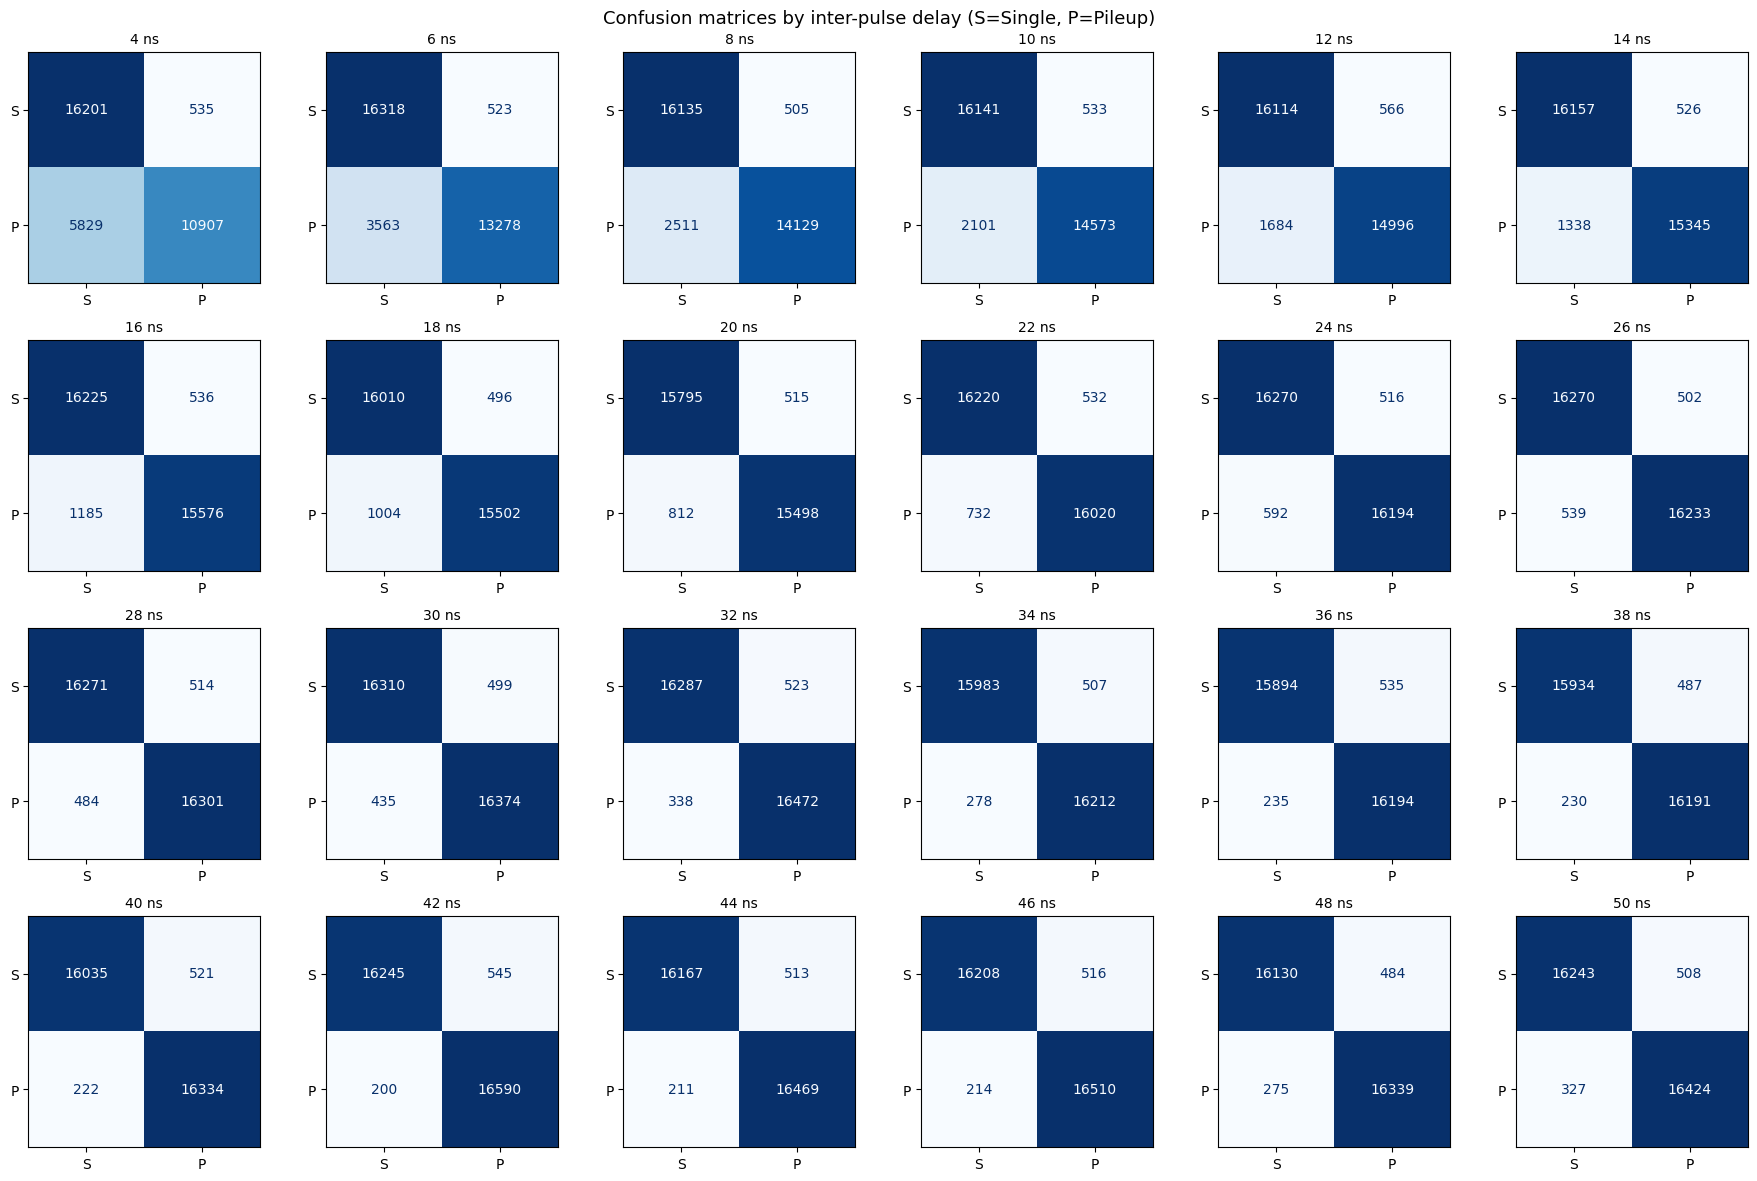

In [ ]:
# --- Confusion matrix for each delay ---
n_delays = len(unique_delays)
ncols = 6
nrows = int(np.ceil(n_delays / ncols))

fig, axes = plt.subplots(nrows, ncols, figsize=(3 * ncols, 3 * nrows))
axes = axes.flatten()

# single-pulse predictions for the singles side of confusion matrices
X_singles_norm = X_singles.copy().astype(np.float32)
norms_s = np.linalg.norm(X_singles_norm, axis=1, keepdims=True)
norms_s[norms_s == 0] = 1.0
X_singles_norm = X_singles_norm / norms_s
single_probs = model.predict(X_singles_norm[..., np.newaxis], batch_size=1024).squeeze()
single_preds = (single_probs > 0.5).astype(int)

for i, d in enumerate(unique_delays):
    ax = axes[i]
    mask = pileup_delays == d
    n_this = mask.sum()

    # Sample same number of singles as pileups for a balanced CM
    s_idx = rng.choice(len(single_preds), size=n_this, replace=False)

    y_true_cm = np.concatenate([np.zeros(n_this, dtype=int), np.ones(n_this, dtype=int)])
    y_pred_cm = np.concatenate([single_preds[s_idx], pileup_preds[mask]])

    cm = confusion_matrix(y_true_cm, y_pred_cm)
    disp = ConfusionMatrixDisplay(cm, display_labels=["S", "P"])
    disp.plot(ax=ax, cmap="Blues", colorbar=False, values_format="d")
    ax.set_title(f"{d * 2} ns", fontsize=10)
    ax.set_xlabel("")
    ax.set_ylabel("")

# Hide unused axes
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

fig.suptitle("Confusion matrices by inter-pulse delay (S=Single, P=Pileup)", fontsize=13)
plt.tight_layout()
plt.show()